# SDMatte wall pipeline

Three ways to tell SDMatte *which* surface to matte:

- **`trimap` (default)** — reuse the wall mask that the **image2scene API** produced for this
  sample (`image2scene/<sample>/wall_mask.png` = raw union of the API's `wall_masks`, written by
  `run_api.py` straight from `original.jpg`). No object subtraction and no Imagen inpainting, so
  this is the wall that is *actually visible* in the photo — walls behind furniture are absent,
  unlike `users_gd/<sample>/wall_mask_visible.png`, which the API produced from an object-removed
  image. Turned into a trimap by **`generate_trimap.make_trimap()`** — the same call
  `main_diff.ipynb` makes, so the two notebooks feed their networks identical input: `1` = definite
  wall, `0` = definite background, `0.5` = the unknown band dilated `TRIMAP_SIZE` px **outward**
  from every boundary. SDMatte takes this natively (`aux_input="trimap"`,
  `trimap_coords=[0,0,1,1]`). **No RAM++/GroundingDINO needed** — the surface is already known,
  so this mode only loads SDMatte (~5 s/sample).
- **`mask`** — GroundingDINO detects walls (positive) and objects (negative); prompt mask = union
  of wall boxes with object boxes zeroed out. Holes are the only negative signal SDMatte has.
- **`points`** — positive point blobs on the walls. Bleeds into wall fixtures (TV, doors, stairs);
  kept for comparison only. SDMatte has **no negative-point channel** (`GenPoint` samples 10 points
  from GT foreground only), so `NEG_MODE="signed"` pushes the prompt out of distribution and
  collapses the alpha. Do not use it.

Reads `image2scene/<sample>/` (read-only, produced by `python run_api.py`), writes everything
to `users_sd/<sample>/`:
`wall_alpha_sdmatte.png`, `wall_mask_sdmatte.png`, `trimap.png`, `overlay.png`, `prompt.json`,
`time.txt` (+ `points.png` / `prompt_mask.png` in the detection modes).

Runs fully local on the 5070 — no Vertex/Imagen billing per call.

## Imports & config

In [1]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# The trimap generator, shared verbatim with main_diff.ipynb (and with the CLI batch mode of
# generate_trimap.py). Importing it is what guarantees the two notebooks cannot drift apart.
from generate_trimap import (wall_trimap, resolve_size, SIZE, METHOD, ITERATIONS,
                             FULL_RES, INNER_SIZE, FILL_HOLES, CUT_OBJECTS, CUT_DILATE)

ROOT = Path.cwd()
SRC_DIR = ROOT / "image2scene"     # read original.jpg + wall_mask.png from here (run_api.py)
GD_DIR = ROOT / "users_gd"         # main_gd/run.py outputs, for the comparison panel only
OUT_DIR = ROOT / "users_sd"        # all outputs land here
SDMATTE_REPO = ROOT / "hq-mat" / "SDMatte"
SDMATTE_WEIGHTS = ROOT / "weights" / "SDMatte"   # HF snapshot: configs + SDMatte.pth
device = "cuda" if torch.cuda.is_available() else "cpu"

# RAM++ (auto-tagging) -> tags become the DINO object prompt (same as main_gd.ipynb)
RAM_CKPT = ROOT / "weights" / "ram_plus_swin_large_14m.pth"
RAM_IMG_SIZE = 384
RAM_VIT = "swin_l"
RAM_EXCLUDE = {
    "window", "doorway", "window blind", "blind", "shutter",
    "hardwood", "tile", "carpet", "flooring", "wood floor", "curtain",
}
RAM_EXCLUDE_KW = ("wall", "floor", "ceiling", "room")  # substring match

# GroundingDINO
DINO_ID = "IDEA-Research/grounding-dino-base"
OBJECT_PROMPT = ("furniture. chair. table. sofa. couch. bed. cabinet. shelf. "
                 "lamp. light. plant. rug. pillow. curtain. tv. picture. frame. "
                 "mirror. vase. appliance. box. decoration. object.")
WALL_PROMPT = "wall."               # positive-surface prompt
NOT_WALL_PROMPT = "ceiling. floor." # carved out of the positive point region
DINO_BOX_THRESH = 0.25
DINO_TEXT_THRESH = 0.20
WALL_BOX_THRESH = 0.20              # walls score lower than objects -> looser
NMS_IOU = 0.5

# SDMatte inference
INFER_SIZE = 1024                   # test pipeline resolution (drop to 512 if OOM)
PROMPT_MODE = "trimap"              # "trimap" = band the raw image2scene wall mask (BEST)
                                    # "mask"   = DINO wall boxes minus object boxes (native negatives)
                                    # "points" = pos points on walls (bleeds into wall fixtures)
OBJ_SUBTRACT = False                # True: matte each object box via SDMatte too, subtract (+~4s/obj)

# trimap mode: which image2scene mask to feed generate_trimap.make_trimap, and how wide the band is
TRIMAP_SRC = "wall_mask.png"          # raw union of the API's wall_masks on the untouched photo:
                                      # visible wall only, no object subtraction, no inpainting
TRIMAP_SIZE = SIZE                  # "0.75%" of the mask's average dimension, clamped to [3,30] px.
TRIMAP_METHOD = METHOD              # "standard" = no fg erosion/dilation before the band.
TRIMAP_ITERATIONS = ITERATIONS      # "0%" -> resolves to 1, and "standard" ignores it anyway.
                                    # The band is dilated OUTWARD only, so the definite foreground
                                    # is exactly the API mask: SDMatte can claim up to TRIMAP_SIZE
                                    # px BEYOND the raw boundary, but can never pull it inward.
                                    # Judge a band change by the pixels GAINED beyond raw, never by
                                    # IoU-vs-raw -- raw is the INPUT, so that score can only fall as
                                    # the band widens.
TRIMAP_FULL_RES = FULL_RES          # build at the mask's native res, one NEAREST downsample at the
                                    # end. Off -> "0.75%" collapses to a constant 8 px at 1024.
TRIMAP_INNER_SIZE = INNER_SIZE      # 0 = never eat wall into unknown (see generate_trimap.py)
TRIMAP_FILL_HOLES = FILL_HOLES      # False = enclosed bg (TV, pictures) stays definite 0
TRIMAP_CUT_OBJECTS = CUT_OBJECTS    # True = band pixels on the BiRefNet object mask -> definite 0
TRIMAP_CUT_DILATE = CUT_DILATE      # px @1024 the object mask is grown before that cut
OBJ_MASK_SRC = "object_mask_birefnet.png"   # read from GD_DIR/<sample>/ for TRIMAP_CUT_OBJECTS
TRIMAP_COMPOSITE = True             # keep the trimap's definite fg/bg verbatim, let SDMatte decide
                                    # only the unknown band. False -> raw SDMatte alpha everywhere
                                    # (softer, and it leaks into objects the API had already cut).
POINT_SIGMA = 35                    # gauss blob sigma @1024 (train radius 25 + 10, test setting)
N_POS = 10                          # GenPoint uses exactly 10 points / 20 coords
NEG_MODE = "off"                    # points mode only: "signed" neg-blob experiment = alpha collapse
OFFICIAL_RESIZE = True              # True: cv2.INTER_LINEAR, the exact op in SDMatte's
                                    # data/dataset.py `Resize` (no antialiasing) -- what the
                                    # checkpoint was trained/evaluated with. False: PIL BILINEAR
                                    # (antialiased, subjectively cleaner, 0.9% of px flip @0.5).
DTYPE = torch.float16               # fp16: ~2.7 GB weights; fits 5070 12GB next to RAM+++DINO
ALPHA_THRESH = 0.5                  # alpha -> binary wall mask

NEED_DETECT = PROMPT_MODE != "trimap"   # trimap mode reuses image2scene masks -> no RAM++/DINO

# heavy models, filled by load_models()
_sdmatte = dino = dino_proc = ram_model = ram_tf = None

## IO helpers

In [2]:
def load_sample(sample_dir: Path):
    """original.jpg -> RGB PIL, EXIF-normalized IN MEMORY (fixes Orientation!=1 samples
    like user_3/user_13 without touching the file on disk)."""
    return ImageOps.exif_transpose(Image.open(sample_dir / "original.jpg")).convert("RGB")


def mask_to_pil(mask) -> Image.Image:
    """Boolean/float mask -> 8-bit L image (255 = wall)."""
    return Image.fromarray((np.asarray(mask) > 0).astype(np.uint8) * 255, mode="L")

## Load models (SDMatte, + RAM++/GroundingDINO only if a detection mode is selected)
SDMatte is built config-only (`load_weight=False` -> diffusers `from_config` on the HF snapshot's
`unet/vae/text_encoder/scheduler/tokenizer`), then the official `SDMatte.pth` is loaded on top.
`weights_only=False` + `mmap=True` are required: the checkpoint is a `DetectionCheckpointer` dict
(`model`/`trainer`/`iteration`) that pickles an omegaconf `ListConfig`.

With `PROMPT_MODE="trimap"` the surface already comes from `image2scene`, so RAM++ and GroundingDINO
are skipped entirely (~4 GB VRAM and ~5 s/sample saved).

In [3]:
def load_detectors():
    """RAM++ + GroundingDINO. Only needed by PROMPT_MODE in ("mask", "points")."""
    global dino, dino_proc, ram_model, ram_tf

    # RAM++ (auto image tagging -> open-vocab labels for DINO)
    from ram.models import ram_plus
    from ram import get_transform
    ram_model = ram_plus(pretrained=str(RAM_CKPT), image_size=RAM_IMG_SIZE,
                         vit=RAM_VIT).eval().to(device)
    ram_tf = get_transform(image_size=RAM_IMG_SIZE)

    # GroundingDINO (open-vocab detection: objects AND walls)
    from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
    dino_proc = AutoProcessor.from_pretrained(DINO_ID)
    dino = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device).eval()


def load_models(detectors=None):
    """Load SDMatte (once), plus RAM++/GroundingDINO unless the prompt comes from image2scene."""
    global _sdmatte

    torch.set_float32_matmul_precision("high")

    if NEED_DETECT if detectors is None else detectors:
        load_detectors()

    # SDMatte (repo import; utils/__init__ patched so detectron2 is not required)
    if str(SDMATTE_REPO) not in sys.path:
        sys.path.insert(0, str(SDMATTE_REPO))
    from modeling.SDMatte import SDMatte
    model_kwargs = dict(                       # = configs/SDMatte.py hy_dict.model_kwargs
        pretrained_model_name_or_path=str(SDMATTE_WEIGHTS),
        load_weight=False,                     # configs come from the snapshot, weights from .pth
        conv_scale=3,
        num_inference_steps=1,
        aux_input="mask",                      # placeholder; _sdmatte_run sets it per call
        add_noise=False,
        use_dis_loss=True,
        use_aux_input=True,
        use_coor_input=True,
        use_attention_mask=True,
        residual_connection=False,
        use_encoder_hidden_states=True,
        use_attention_mask_list=[True, True, True],
        use_encoder_hidden_states_list=[False, True, False],
    )
    _sdmatte = SDMatte(**model_kwargs)
    # weights_only=False: official vivo checkpoint pickles its omegaconf training config
    # (keys: model/trainer/iteration). Needs `pip install omegaconf` in this env.
    sd = torch.load(SDMATTE_WEIGHTS / "SDMatte.pth", map_location="cpu",
                    mmap=True, weights_only=False)
    if "model" in sd and isinstance(sd["model"], dict):   # DetectionCheckpointer layout
        sd = sd["model"]
    missing, unexpected = _sdmatte.load_state_dict(sd, strict=False)
    print(f"SDMatte state_dict: {len(missing)} missing / {len(unexpected)} unexpected")
    assert not missing, f"missing keys, checkpoint mismatch: {missing[:5]}"
    _sdmatte = _sdmatte.to(device, DTYPE).eval()
    del sd
    torch.cuda.empty_cache()

    print(f"models ready on {device} | SDMatte {DTYPE} @ {INFER_SIZE}px | mode={PROMPT_MODE}"
          f" | detectors={'yes' if dino is not None else 'skipped'}")


load_models()

/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


add aux_conv_in layer for unet
Unet conv_in layer is replaced
Unet config is updated


SDMatte state_dict: 0 missing / 0 unexpected


models ready on cuda | SDMatte torch.float16 @ 1024px | mode=trimap | detectors=skipped


## 1. GroundingDINO: objects (negative) + walls (positive)

In [4]:
def _filter_ram_tags(tags):
    """Drop structural/scene tags; lowercase + dedupe, preserve order."""
    out, seen = [], set()
    for t in tags:
        t = t.strip().lower()
        if (not t) or t in RAM_EXCLUDE or t in seen:
            continue
        if any(k in t for k in RAM_EXCLUDE_KW):
            continue
        seen.add(t)
        out.append(t)
    return out


@torch.no_grad()
def ram_autotag(image: Image.Image):
    """RAM++ auto-labels the image -> (DINO prompt string, tag list)."""
    from ram import inference_ram
    res = inference_ram(ram_tf(image).unsqueeze(0).to(device), ram_model)
    tags = _filter_ram_tags(res[0].split(" | "))
    prompt = (". ".join(tags) + ".") if tags else OBJECT_PROMPT
    return prompt, tags


@torch.no_grad()
def detect(image: Image.Image, prompt,
           box_thresh=DINO_BOX_THRESH, text_thresh=DINO_TEXT_THRESH, nms_iou=NMS_IOU):
    """GroundingDINO open-vocab -> ([x1,y1,x2,y2] boxes, labels)."""
    from torchvision.ops import nms
    inp = dino_proc(images=image, text=prompt, return_tensors="pt").to(device)
    out = dino(**inp)
    res = dino_proc.post_process_grounded_object_detection(
        out, inp["input_ids"], threshold=box_thresh, text_threshold=text_thresh,
        target_sizes=[image.size[::-1]])[0]
    boxes, scores = res["boxes"], res["scores"]
    labels = list(res.get("text_labels", res.get("labels", [])))
    if nms_iou is not None and len(boxes):
        keep = nms(boxes, scores, nms_iou).tolist()
        boxes = boxes[keep]
        labels = [labels[i] for i in keep]
    return [[float(v) for v in b] for b in boxes.tolist()], labels


def detect_objects(image, prompt=None):
    """RAM++ tags -> DINO object boxes (negative regions)."""
    if prompt is None:
        prompt, _ = ram_autotag(image)
    return detect(image, prompt)


def detect_walls(image):
    """DINO 'wall.' boxes (positive regions)."""
    return detect(image, WALL_PROMPT, box_thresh=WALL_BOX_THRESH)


def detect_not_walls(image):
    """DINO ceiling/floor boxes -- carved out of the positive POINT region (GD wall boxes
    are often near-full-frame; without this, positive points leak onto ceiling/floor)."""
    return detect(image, NOT_WALL_PROMPT, box_thresh=WALL_BOX_THRESH)

## 2. Prompt construction
- **trimap mode (default)**: read `image2scene/<sample>/wall_mask.png` (the raw union of the
  image2scene API's wall masks, run directly on `original.jpg`) and hand it to
  `generate_trimap.make_trimap()`, which dilates it outward and labels the ring `0.5`.
  `1` = definite wall, `0` = definite background, `0.5` = "SDMatte, you decide". `TRIMAP_SIZE`
  is how much slack the API mask gets, and it is slack in the outward direction only.
- **mask mode**: prompt mask = union of wall boxes with all object boxes zeroed out.
  The holes are the only "negative" signal SDMatte understands (there is no negative-point channel).
- **points mode**: `N_POS` gaussian blobs (`sigma=POINT_SIGMA`) on wall pixels, sampled by
  farthest-point sampling inside the wall boxes after carving out objects + ceiling/floor.

In [5]:
def _carve(region, box, size, grid, pad=0.10):
    """Zero a (padded) pixel box out of the low-res candidate grid."""
    w, h = size
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    gx1 = max(0, int((x1 - pad * bw) / w * grid)); gx2 = min(grid, int(np.ceil((x2 + pad * bw) / w * grid)))
    gy1 = max(0, int((y1 - pad * bh) / h * grid)); gy2 = min(grid, int(np.ceil((y2 + pad * bh) / h * grid)))
    region[gy1:gy2, gx1:gx2] = False


def _fps(cands, n, seed=0):
    """Greedy farthest-point sampling -> n spread-out points."""
    if len(cands) <= n:
        return cands
    rng = np.random.default_rng(seed)
    pts = [cands[rng.integers(len(cands))]]
    cands = np.asarray(cands)
    d = np.linalg.norm(cands - pts[0], axis=1)
    for _ in range(n - 1):
        i = int(d.argmax())
        pts.append(cands[i])
        d = np.minimum(d, np.linalg.norm(cands - cands[i], axis=1))
    return [tuple(p) for p in pts]


def wall_points(size, wall_boxes, obj_boxes, not_wall_boxes=(), n=N_POS, grid=64):
    """Positive point prompts (normalized x,y in 0..1): inside wall boxes, outside
    (padded) object boxes and outside ceiling/floor boxes."""
    w, h = size
    region = np.zeros((grid, grid), bool)
    if wall_boxes:
        for x1, y1, x2, y2 in wall_boxes:
            region[int(y1 / h * grid):int(np.ceil(y2 / h * grid)),
                   int(x1 / w * grid):int(np.ceil(x2 / w * grid))] = True
    else:
        region[: grid // 2, :] = True          # no wall box -> assume walls in the top half
    carved = region.copy()
    for b in obj_boxes:
        _carve(carved, b, size, grid)
    for b in not_wall_boxes:                   # ceiling/floor: no pad, boxes are huge already
        _carve(carved, b, size, grid, pad=0.0)
    if not carved.any():                       # ceiling/floor ate everything -> objects only
        print("  WARN: ceiling/floor boxes cover all wall area, carving objects only")
        carved = region
        for b in obj_boxes:
            _carve(carved, b, size, grid)
    if not carved.any():                       # objects cover every wall box -> keep raw walls
        print("  WARN: object boxes cover all wall area, sampling inside wall boxes anyway")
        carved = region
    ys, xs = np.where(carved)
    cands = [((x + 0.5) / grid, (y + 0.5) / grid) for y, x in zip(ys, xs)]
    return _fps(cands, n)


def object_centers(size, obj_boxes, n=N_POS):
    """Negative point prompts = object box centers (normalized), biggest boxes first."""
    w, h = size
    boxes = sorted(obj_boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]), reverse=True)
    return [(((x1 + x2) / 2) / w, ((y1 + y2) / 2) / h) for x1, y1, x2, y2 in boxes[:n]]


def build_point_mask(hw, pts, sigma=POINT_SIGMA):
    """Gauss blob per point, peak 1 (matches GenPoint psm='gauss'), float32 in [0,1]."""
    h, w = hw
    m = np.zeros((h, w), np.float32)
    r = int(3 * sigma)
    ax = np.arange(-r, r + 1, dtype=np.float32)
    patch = np.exp(-(ax[None] ** 2 + ax[:, None] ** 2) / (2 * sigma ** 2))
    for xn, yn in pts:
        cx, cy = int(xn * (w - 1)), int(yn * (h - 1))
        x0, x1 = max(0, cx - r), min(w, cx + r + 1)
        y0, y1 = max(0, cy - r), min(h, cy + r + 1)
        m[y0:y1, x0:x1] = np.maximum(m[y0:y1, x0:x1],
                                     patch[y0 - (cy - r):y1 - (cy - r), x0 - (cx - r):x1 - (cx - r)])
    return m


def boxes_to_mask(size, boxes, subtract=(), out=INFER_SIZE):
    """Pixel boxes -> [0,1] prompt mask at (out,out); `subtract` boxes are zeroed (negatives)."""
    w, h = size
    m = np.zeros((out, out), np.float32)
    for x1, y1, x2, y2 in boxes:
        m[int(y1 / h * out):int(np.ceil(y2 / h * out)),
          int(x1 / w * out):int(np.ceil(x2 / w * out))] = 1.0
    for x1, y1, x2, y2 in subtract:
        m[int(y1 / h * out):int(np.ceil(y2 / h * out)),
          int(x1 / w * out):int(np.ceil(x2 / w * out))] = 0.0
    return m


def mask_bbox(m01):
    """Bounding box of a [0,1] mask, normalized [x1,y1,x2,y2] (SDMatte mask_coords)."""
    ys, xs = np.where(m01 > 0)
    if not len(ys):
        return [0.0, 0.0, 1.0, 1.0]
    return [xs.min() / m01.shape[1], ys.min() / m01.shape[0],
            xs.max() / m01.shape[1], ys.max() / m01.shape[0]]


def load_object_mask(sample_name, shape):
    """BiRefNet object mask for TRIMAP_CUT_OBJECTS, resized to `shape`. None if absent/disabled."""
    if not TRIMAP_CUT_OBJECTS:
        return None
    path = GD_DIR / sample_name / OBJ_MASK_SRC
    if not path.exists():
        print(f"  WARN: no {path}, band will not be cut against objects")
        return None
    obj = np.asarray(Image.open(path).convert("L"))
    if obj.shape[:2] != tuple(shape[:2]):
        obj = cv2.resize(obj, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
    return obj


_UNSET = object()


def build_trimap(sample_dir, size=INFER_SIZE, src=None,
                 band=None, method=None, iterations=None, object_mask=_UNSET, **kw):
    """image2scene surface mask -> SDMatte trimap at (size,size): 0 = bg, 0.5 = unknown, 1 = fg.

    Delegates to `generate_trimap.wall_trimap()` -- the same call `main_diff.ipynb` makes, wrapping
    the same `make_trimap` the CLI batch in `generate_trimap.py` runs. The band is dilated OUTWARD
    only, so the definite foreground stays exactly the API's wall mask; the wall-specific policy
    (inner band, hole handling, object cut, full-res build) lives in `wall_trimap` so the two
    notebooks cannot drift apart."""
    src = src or TRIMAP_SRC

    path = sample_dir / src
    if not path.exists():
        raise FileNotFoundError(f"{path} -- trimap mode needs the image2scene masks for this "
                                f"sample; run `python run_api.py` first")

    m = np.asarray(Image.open(path).convert("L"))
    return wall_trimap(
        m, out_size=size,
        size=TRIMAP_SIZE if band is None else band,
        method=TRIMAP_METHOD if method is None else method,
        iterations=TRIMAP_ITERATIONS if iterations is None else iterations,
        full_res=TRIMAP_FULL_RES, inner_size=TRIMAP_INNER_SIZE, fill_holes=TRIMAP_FILL_HOLES,
        object_mask=(load_object_mask(sample_dir.name, m.shape) if object_mask is _UNSET
                     else object_mask),
        cut_dilate=TRIMAP_CUT_DILATE, name=sample_dir.name, **kw)


TRIMAP_LUT = np.array([0, 128, 255], np.uint8)     # bg / unknown / fg -> 8-bit preview


def trimap_to_pil(tri, size=None):
    """[0,0.5,1] trimap -> 8-bit L image (0 bg / 128 unknown / 255 fg), optionally resized."""
    im = Image.fromarray(TRIMAP_LUT[np.rint(tri * 2).astype(np.uint8)], mode="L")
    return im.resize(size, Image.NEAREST) if size else im


def load_trimap_file(path, size=INFER_SIZE):
    """Read a ready-made 3-level trimap (0 / 128 / 255) -> [0, 0.5, 1] at (size,size).

    Same convention as SDMatte's `DataGenerator.__getitem__` (`trimap[trimap==128]=0.5`,
    `trimap[trimap==255]=1.0`), resized with `cv2.INTER_NEAREST` like their `GenTrimap`.
    Anything that is not exactly 128 or 255 is background, so antialiased edges read as bg --
    which is why the resize must stay NEAREST."""
    tri = np.asarray(Image.open(path).convert("L"), np.float32)
    levels = set(np.unique(tri).tolist())
    if not levels <= {0.0, 127.0, 128.0, 255.0}:
        raise ValueError(f"{path}: expected a 0/127|128/255 trimap, got {len(levels)} levels "
                         f"({sorted(levels)[:6]}...). Use build_trimap() for a binary mask.")
    out = np.zeros_like(tri)
    out[(tri == 127) | (tri == 128)] = 0.5      # 127 = generate_trimap.py, 128 = the previews here
    out[tri == 255] = 1.0
    return cv2.resize(out, (size, size), interpolation=cv2.INTER_NEAREST)



## 3. SDMatte inference
`_sdmatte_run` replicates the repo's test pipeline (`DataGenerator phase="test"` + `inference.py`):
resize to `INFER_SIZE`, map image and prompt to `[-1,1]` (`*2-1`), `is_trans=0`, empty caption,
one DDIM step. `model.aux_input` picks which prompt channel the UNet conditions on, and each type
has its own coordinate key (`AUX_INPUT_DIT` in `modeling/SDMatte/meta_arch.py`).

**Why not just call their `inference.py`?** It needs `detectron2` (`LazyConfig`, `instantiate`,
`DetectionCheckpointer`) and so does `configs/SDMatte.py` (`model_zoo`, `fvcore`,
`WarmupParamScheduler`) — all of it training/eval scaffolding. detectron2 has no wheel for
torch 2.12 / cu130 and builds a C++ extension, which this box cannot do (no `g++`). Their
`data/dataset.py` is detectron2-free though, so the *settings* are taken from there directly and
checked against this code:

| setting | official (`data/dataset.py`) | here |
|---|---|---|
| test resolution | `Resize((1024, 1024))` | `INFER_SIZE = 1024` |
| image resize | `cv2.INTER_LINEAR`, no antialias | `OFFICIAL_RESIZE=True` -> same op |
| trimap resize | `cv2.INTER_NEAREST` (`GenTrimap`) | same |
| trimap levels | `0 / 0.5 / 1` -> `*2-1` (`Normalize`) | same |
| `trimap_coords` | `[0, 0, 1, 1]` (`Gen_Add_Mask_Coord`) | same |
| point sigma | `radius + 10 = 35` at test | `POINT_SIGMA = 35` |

Trimap is a first-class `aux_input`: because `"trimap"` is not in `attn_mask_aux_input`, no
attention mask is derived from it — the three levels reach the UNet as `-1 / 0 / +1`.

SDMatte runs at 1024², so its alpha comes back softer than the full-resolution API mask and drifts
inside regions the trimap already called. `TRIMAP_COMPOSITE` restores the usual trimap-matting
contract: definite fg stays 1, definite bg stays 0, and the network only fills the unknown band.

In [6]:
_COORD_KEY = {"point_mask": "point_coords", "bbox_mask": "bbox_coords",
              "mask": "mask_coords", "trimap": "trimap_coords"}


def _resize_image(image: Image.Image, size):
    """RGB PIL -> float32 [0,1] (size,size,3).

    OFFICIAL_RESIZE reproduces `Resize` in SDMatte's `data/dataset.py`: the image is read as
    float [0,1] and downscaled with cv2.INTER_LINEAR, which does *not* antialias. PIL's BILINEAR
    does, so it disagrees with the official pipeline on ~9% of pixels and flips ~0.9% of the
    thresholded wall mask. Match the checkpoint's own preprocessing by default."""
    arr = np.asarray(image, np.float32) / 255.0
    if OFFICIAL_RESIZE:
        return cv2.resize(arr, (size, size), interpolation=cv2.INTER_LINEAR)
    return np.asarray(image.resize((size, size), Image.BILINEAR), np.float32) / 255.0


@torch.no_grad()
def _sdmatte_run(image: Image.Image, aux_type, aux01, coords, size=INFER_SIZE):
    """One SDMatte forward -> float alpha (H, W) in [0,1] at original size.
    aux01: [0,1] float prompt mask at (size,size). coords: flat list of floats."""
    w, h = image.size
    im = _resize_image(image, size)
    _sdmatte.aux_input = aux_type
    data = {
        "image": torch.from_numpy(im.transpose(2, 0, 1))[None].to(device, DTYPE) * 2 - 1,
        aux_type: torch.from_numpy(aux01 * 2 - 1)[None, None].to(device, DTYPE),
        _COORD_KEY[aux_type]: torch.tensor(coords)[None].to(device, DTYPE),
        "is_trans": torch.tensor([0]).long().to(device),
        "caption": [""],
    }
    pred = _sdmatte(data)                                  # [1,1,size,size] in [0,1]
    alpha = pred[0, 0].float().cpu().numpy()
    torch.cuda.empty_cache()
    return cv2.resize(alpha, (w, h), interpolation=cv2.INTER_LINEAR)


def sdmatte_alpha_trimap(image, trimap, composite=None):
    """BEST: trimap from the image2scene wall mask. 0/0.5/1 -> -1/0/+1, coords fixed at [0,0,1,1].

    With `composite`, only the unknown band keeps SDMatte's alpha: the definite fg/bg of the
    full-resolution trimap wins over the 1024-px network output (sharper, and no leaking into
    objects the API already removed)."""
    alpha = _sdmatte_run(image, "trimap", trimap, [0.0, 0.0, 1.0, 1.0])
    if TRIMAP_COMPOSITE if composite is None else composite:
        tri = np.asarray(trimap_to_pil(trimap, image.size), np.float32) / 255.0  # 0 / ~0.5 / 1
        alpha = np.where(tri > 0.9, 1.0, np.where(tri < 0.1, 0.0, alpha)).astype(np.float32)
    return alpha


def sdmatte_alpha_mask(image, wall_boxes, obj_boxes):
    """BEST: prompt mask = wall boxes minus object boxes (holes = native negative signal)."""
    m = boxes_to_mask(image.size, wall_boxes if wall_boxes
                      else [[0, 0, image.size[0], image.size[1] * 0.5]], subtract=obj_boxes)
    return _sdmatte_run(image, "mask", m, mask_bbox(m))


def sdmatte_alpha_points(image, pos_pts, neg_pts=(), neg_mode=None):
    """Point prompts (positive-only; neg blobs only in the "signed" experiment)."""
    if neg_mode is None:
        neg_mode = NEG_MODE            # resolved at call time -> config-cell edits apply
    pm = build_point_mask((INFER_SIZE, INFER_SIZE), pos_pts)
    if neg_mode == "signed" and len(neg_pts):
        # EXPERIMENT: negative blobs below background -> OOD, collapses alpha. Keep "off".
        pm = np.clip(pm, 0, 1) - build_point_mask((INFER_SIZE, INFER_SIZE), neg_pts)
    coords = []
    for x, y in list(pos_pts)[:N_POS]:
        coords += [x, y]
    coords += [0.0] * (2 * N_POS - len(coords))            # GenPoint pads to 20 floats
    return _sdmatte_run(image, "point_mask", np.clip(pm, -1, 1), coords)


def sdmatte_alpha_bbox(image, box):
    """Single-box prompt (used per object for OBJ_SUBTRACT)."""
    w, h = image.size
    m = boxes_to_mask(image.size, [box])
    return _sdmatte_run(image, "bbox_mask", m, [box[0] / w, box[1] / h, box[2] / w, box[3] / h])


def sdmatte_objects(image, obj_boxes):
    """Union of per-object SDMatte bbox mattes (~4s/object)."""
    w, h = image.size
    out = np.zeros((h, w), np.float32)
    for b in obj_boxes:
        out = np.maximum(out, sdmatte_alpha_bbox(image, b))
    return out

## 4. Full pipeline

In [7]:
POS_COLOR, NEG_COLOR = (60, 220, 60), (230, 40, 40)
def _points_viz(img, pos_pts, neg_pts, radius=14):
    """Draw pos (green) / neg (red) point prompts on a copy of the image."""
    vis = np.asarray(img).copy()
    w, h = img.size
    for pts, col in ((pos_pts, POS_COLOR), (neg_pts, NEG_COLOR)):
        for x, y in pts:
            cv2.circle(vis, (int(x * w), int(y * h)), radius, col, -1, cv2.LINE_AA)
            cv2.circle(vis, (int(x * w), int(y * h)), radius, (255, 255, 255), 2, cv2.LINE_AA)
    return vis


def run_pipeline_sd(sample_dir: Path, thresh=ALPHA_THRESH, mode=None):
    """SDMatte wall alpha for one sample. Reads image2scene/<sample>/, writes users_sd/<sample>/.

    trimap mode: image2scene wall_mask.png -> trimap -> SDMatte (no detection at all).
    mask/points mode: RAM++ -> DINO objects (neg) + walls (pos) -> visual prompt -> SDMatte."""
    mode = mode or PROMPT_MODE
    out_dir = OUT_DIR / sample_dir.name
    out_dir.mkdir(parents=True, exist_ok=True)
    img = load_sample(sample_dir)

    timings, t0 = {}, time.time()

    def _t(name, since):
        timings[name] = time.time() - since
        print(f"  {name} done in {timings[name]:.1f}s")
        return time.time()

    start = time.time()
    trimap = None
    obj_prompt, obj_tags = "", []
    obj_boxes = wall_boxes = nw_boxes = []
    obj_labels = wall_labels = nw_labels = []
    pos_pts = neg_pts = []

    if mode == "trimap":
        # 1. prompt = banded image2scene wall mask (visible wall, this sample, no detection)
        trimap = build_trimap(sample_dir)
        start = _t("trimap", start)
        # 2. SDMatte
        alpha = sdmatte_alpha_trimap(img, trimap)
    else:
        if dino is None:
            raise RuntimeError(f"mode={mode} needs RAM++/DINO -- run load_detectors() first")
        # 1. detection: RAM++ tags -> object boxes (negative), 'wall.' -> wall boxes (positive)
        obj_prompt, obj_tags = ram_autotag(img)
        obj_boxes, obj_labels = detect_objects(img, prompt=obj_prompt)
        wall_boxes, wall_labels = detect_walls(img)
        nw_boxes, nw_labels = detect_not_walls(img)
        start = _t("ram_dino", start)

        # 2. prompts (points always computed -- cheap, useful viz even in mask mode)
        pos_pts = wall_points(img.size, wall_boxes, obj_boxes, nw_boxes)
        neg_pts = object_centers(img.size, obj_boxes)
        start = _t("points", start)

        # 3. SDMatte wall alpha
        alpha = (sdmatte_alpha_mask(img, wall_boxes, obj_boxes) if mode == "mask"
                 else sdmatte_alpha_points(img, pos_pts, neg_pts))
    start = _t(f"sdmatte_{mode}", start)

    # 3b. optional: subtract SDMatte object mattes (marginal gain, +~4s/object)
    obj_alpha = None
    if OBJ_SUBTRACT and obj_boxes:
        obj_alpha = sdmatte_objects(img, obj_boxes)
        alpha = np.clip(alpha - obj_alpha, 0, 1)
        Image.fromarray((obj_alpha * 255).astype(np.uint8), "L").save(
            out_dir / "object_alpha_sdmatte.png")
        start = _t("obj_subtract", start)

    wall = alpha >= thresh

    # 4. outputs
    Image.fromarray((alpha * 255).astype(np.uint8), "L").save(out_dir / "wall_alpha_sdmatte.png")
    mask_to_pil(wall).save(out_dir / "wall_mask_sdmatte.png")
    if mode == "trimap":
        trimap_to_pil(trimap, img.size).save(out_dir / "trimap.png")
    else:
        Image.fromarray(_points_viz(img, pos_pts, neg_pts)).save(out_dir / "points.png")
        if mode == "mask":
            pm = boxes_to_mask(img.size, wall_boxes, subtract=obj_boxes)
            Image.fromarray((pm * 255).astype(np.uint8), "L").save(out_dir / "prompt_mask.png")
    overlay = np.asarray(img).astype(np.float32)
    overlay[wall] = 0.5 * overlay[wall] + 0.5 * np.array((0, 130, 200), np.float32)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(out_dir / "overlay.png")
    (out_dir / "prompt.json").write_text(json.dumps(
        {"prompt_mode": mode, "obj_subtract": OBJ_SUBTRACT, "neg_mode": NEG_MODE,
         "trimap_composite": TRIMAP_COMPOSITE if mode == "trimap" else None,
         "trimap_src": TRIMAP_SRC if mode == "trimap" else None,
         "trimap_generator": "generate_trimap.wall_trimap" if mode == "trimap" else None,
         "trimap_cfg": ({"size": TRIMAP_SIZE, "method": TRIMAP_METHOD,
                         "iterations": TRIMAP_ITERATIONS, "full_res": TRIMAP_FULL_RES,
                         "inner_size": TRIMAP_INNER_SIZE, "fill_holes": TRIMAP_FILL_HOLES,
                         "cut_objects": TRIMAP_CUT_OBJECTS, "cut_dilate": TRIMAP_CUT_DILATE}
                        if mode == "trimap" else None),
         "pos": pos_pts, "neg": neg_pts,
         "wall_boxes": wall_boxes, "not_wall_boxes": nw_boxes,
         "obj_boxes": obj_boxes, "obj_labels": list(map(str, obj_labels))},
        indent=1))
    timings["total"] = time.time() - t0
    (out_dir / "time.txt").write_text(
        "\n".join(f"{k:<16s} {v:8.2f}s" for k, v in timings.items()) + "\n")
    print(f"  TOTAL {timings['total']:.1f}s -> {out_dir}")

    return {"img": img, "alpha": alpha, "wall": wall, "obj_alpha": obj_alpha, "trimap": trimap,
            "mode": mode, "pos_pts": pos_pts, "neg_pts": neg_pts,
            "wall_boxes": wall_boxes, "wall_labels": wall_labels,
            "nw_boxes": nw_boxes, "nw_labels": nw_labels,
            "obj_boxes": obj_boxes, "obj_labels": obj_labels,
            "obj_prompt": obj_prompt, "obj_tags": obj_tags, "timings": timings}

## Run on one sample

In [8]:
SAMPLE = "user_11"          # any folder under image2scene/

res = run_pipeline_sd(SRC_DIR / SAMPLE)
print("mode:", res["mode"], "| walls:", len(res["wall_boxes"]),
      "| objects:", len(res["obj_boxes"]), "| obj_subtract:", OBJ_SUBTRACT)

  trimap done in 0.5s


/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/diffusers/models/unets/unet_2d_blocks.py:1351: FutureWarning: `scale` is deprecated and will be removed in version 1.0.0. The `scale` argument is deprecated and will be ignored. Please remove it, as passing it will raise an error in the future. `scale` should directly be passed while calling the underlying pipeline component i.e., via `cross_attention_kwargs`.
  deprecate("scale", "1.0.0", deprecation_message)
/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/diffusers/models/unets/unet_2d_blocks.py:2535: FutureWarning: `scale` is deprecated and will be removed in version 1.0.0. The `scale` argument is deprecated and will be ignored. Please remove it, as passing it will raise an error in the future. `scale` should directly be passed while calling the underlying pipeline component i.e., via `cross_attention_kwargs`.
  deprecate("scale", "1.0.0", deprecation_message)


  sdmatte_trimap done in 2.1s


  TOTAL 9.1s -> /home/krist/works/refine-mask/users_sd/user_11
mode: trimap | walls: 0 | objects: 0 | obj_subtract: False


## GroundingDINO boxes (detection modes only: walls = blue, objects = red, ceiling/floor = orange dashed)

In [9]:
if res["mode"] == "trimap":
    print('trimap mode: no detection ran -- skip this cell')
else:
    img = res["img"]
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.imshow(img)
    for (x1, y1, x2, y2), l in zip(res["wall_boxes"], res["wall_labels"]):
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="tab:blue", lw=2.5))
        ax.text(x1, y1 - 4, str(l), color="tab:blue", fontsize=9, weight="bold")
    for (x1, y1, x2, y2), l in zip(res["obj_boxes"], res["obj_labels"]):
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="tab:red", lw=1.5))
        ax.text(x1, y2 + 12, str(l), color="tab:red", fontsize=8)
    for (x1, y1, x2, y2), l in zip(res["nw_boxes"], res["nw_labels"]):
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="tab:orange",
                                   lw=1.5, linestyle="--"))
        ax.text(x1, y1 - 4, str(l), color="tab:orange", fontsize=8)
    ax.set_title(f"walls={len(res['wall_boxes'])}  objects={len(res['obj_boxes'])}  "
                 f"ceiling/floor={len(res['nw_boxes'])}")
    ax.axis("off")
    plt.tight_layout()

trimap mode: no detection ran -- skip this cell


## Prompt actually fed to SDMatte

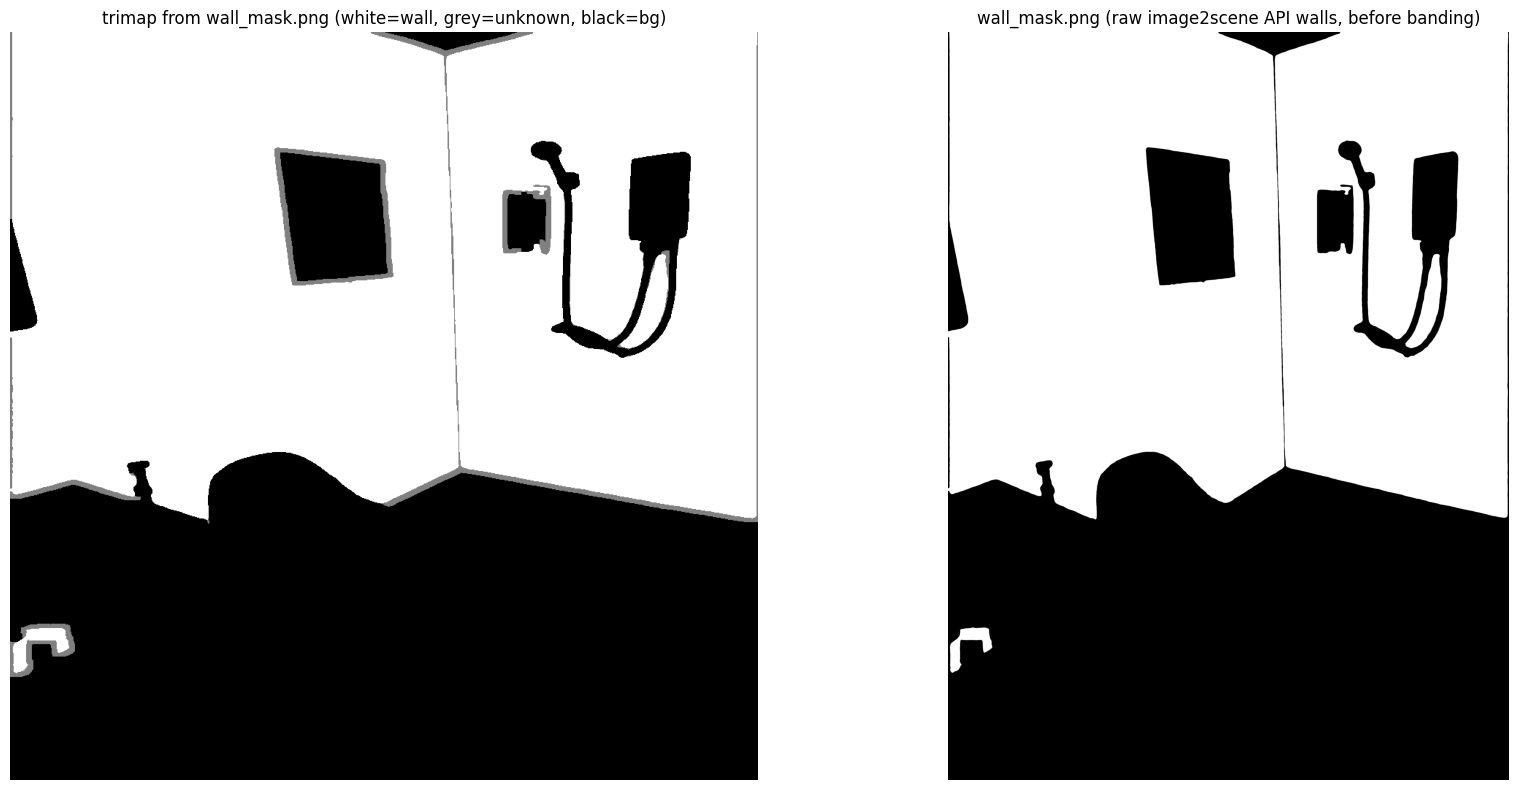

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
if res["mode"] == "trimap":
    ax[0].imshow(res["trimap"], cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"trimap from {TRIMAP_SRC} (white=wall, grey=unknown, black=bg)")
    ax[1].imshow(Image.open(SRC_DIR / SAMPLE / TRIMAP_SRC), cmap="gray")
    ax[1].set_title(f"{TRIMAP_SRC} (raw image2scene API walls, before banding)")
else:
    if res["mode"] == "mask":
        pm = boxes_to_mask(res["img"].size, res["wall_boxes"], subtract=res["obj_boxes"])
        ax[0].set_title("prompt mask (wall boxes minus object boxes -- holes = negatives)")
    else:
        pm = build_point_mask((INFER_SIZE, INFER_SIZE), res["pos_pts"]) * 2 - 1
        ax[0].set_title("point_mask (normalized)")
    ax[0].imshow(pm, cmap="gray" if res["mode"] == "mask" else "coolwarm", vmin=-1, vmax=1)
    ax[1].imshow(_points_viz(res["img"], res["pos_pts"], res["neg_pts"]))
    ax[1].set_title("pos (green) / neg (red) points -- used by mode='points'")
for a in ax:
    a.axis("off")
plt.tight_layout()

## SDMatte result: alpha, binary wall, overlay (+ main_gd wall for comparison)

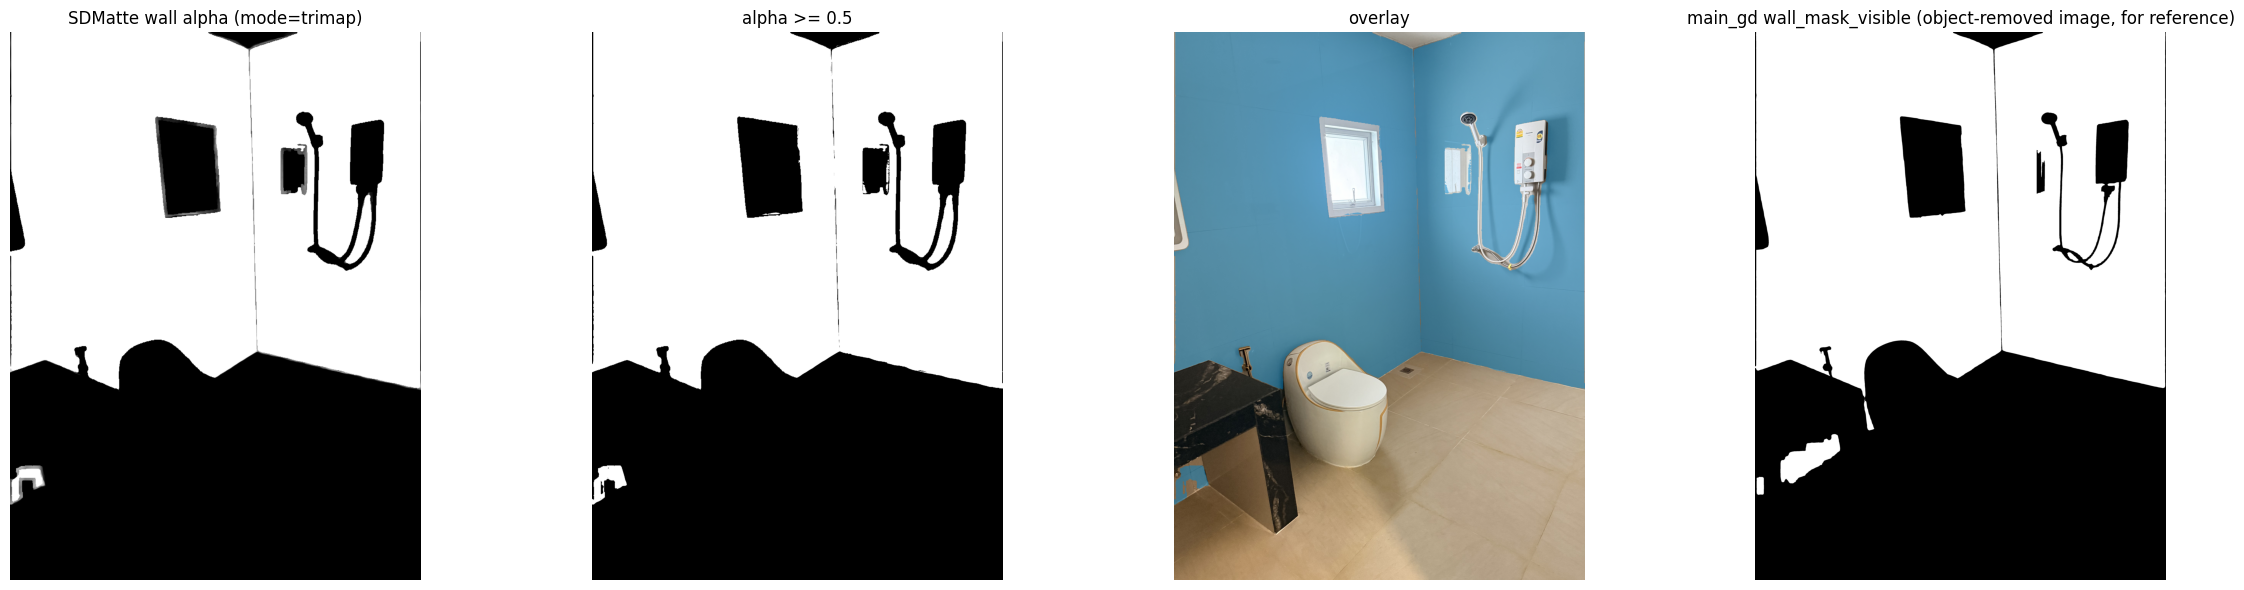

In [11]:
gd_wall_path = GD_DIR / SAMPLE / "wall_mask_visible.png"   # run.py: API on the inpainted image
n = 4 if gd_wall_path.exists() else 3
fig, ax = plt.subplots(1, n, figsize=(6 * n, 6))
ax[0].imshow(res["alpha"], cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"SDMatte wall alpha (mode={res['mode']})")
ax[1].imshow(res["wall"], cmap="gray")
ax[1].set_title(f"alpha >= {ALPHA_THRESH}")
ax[2].imshow(Image.open(OUT_DIR / SAMPLE / "overlay.png"))
ax[2].set_title("overlay")
if n == 4:
    ax[3].imshow(Image.open(gd_wall_path), cmap="gray")
    ax[3].set_title("main_gd wall_mask_visible (object-removed image, for reference)")
for a in ax:
    a.axis("off")
plt.tight_layout()

## Diagnostics: is SDMatte mattting the WALL, or the objects?

Two questions the IoU-vs-raw number cannot answer.

**1. Reach vs leak.** Raw is the *input*, so IoU-vs-raw can only fall as the band widens — judge a
band change by the pixels **GAINED beyond raw** and by what share of them land on furniture.

**2. Inversion check.** Split the *raw* alpha (before compositing) inside the unknown band by the
BiRefNet object mask. If `band ∩ object` mean alpha is low and `band ∩ wall` is high, the model is
behaving correctly; both collapsing together is a wall-loss failure, not an inversion.

In [12]:
def diagnose(sample_dir, thresh=ALPHA_THRESH):
    """Reach/leak + inversion numbers for one sample. Runs SDMatte once with composite OFF.

    The trimap here is built with the object cut DISABLED on purpose: with `CUT_OBJECTS=True` the
    band contains no object pixels by construction, so the `band n object` split would be empty and
    the inversion question unanswerable. This measures what the model does when it *is* offered
    object pixels in the band."""
    img = load_sample(sample_dir)
    trimap = build_trimap(sample_dir, object_mask=None)
    raw = sdmatte_alpha_trimap(img, trimap, composite=False)

    tri_full = np.asarray(trimap_to_pil(trimap, img.size), np.float32) / 255.0
    band = (tri_full > 0.1) & (tri_full < 0.9)
    rawmask = np.asarray(Image.open(sample_dir / TRIMAP_SRC).convert("L")) > 127
    if rawmask.shape != raw.shape:
        rawmask = cv2.resize(rawmask.astype(np.uint8), (raw.shape[1], raw.shape[0]),
                             interpolation=cv2.INTER_NEAREST).astype(bool)

    wall = raw >= thresh
    gained = wall & ~rawmask                      # claimed beyond the API mask
    kept = (wall & rawmask).sum()

    obj = load_object_mask(sample_dir.name, raw.shape)
    obj = (obj > 127) if obj is not None else np.zeros_like(wall)

    print(f"{sample_dir.name}:")
    print(f"  raw-wall recall      {100 * kept / max(1, rawmask.sum()):.1f}%   "
          f"(wall px kept of the API mask)")
    print(f"  gained beyond raw    {gained.sum() / 1000:.1f}k px   "
          f"of which on objects {100 * (gained & obj).sum() / max(1, gained.sum()):.1f}%")
    if band.any() and obj.any():
        bo, bw = band & obj, band & ~obj
        print(f"  band n object  mean alpha {raw[bo].mean():.2f}  "
              f"({100 * (raw[bo] >= thresh).mean():.0f}% called wall)  [want LOW]")
        print(f"  band n wall    mean alpha {raw[bw].mean():.2f}  "
              f"({100 * (raw[bw] >= thresh).mean():.0f}% called wall)  [want HIGH]")
    return {"raw": raw, "band": band, "gained": gained, "obj": obj}


for s in ("user_8", "user_3", "user_14"):
    diagnose(SRC_DIR / s)

user_8:
  raw-wall recall      97.7%   (wall px kept of the API mask)
  gained beyond raw    41.4k px   of which on objects 40.7%
  band n object  mean alpha 0.08  (5% called wall)  [want LOW]
  band n wall    mean alpha 0.18  (17% called wall)  [want HIGH]


user_3:
  raw-wall recall      99.9%   (wall px kept of the API mask)
  gained beyond raw    280.8k px   of which on objects 35.6%
  band n object  mean alpha 0.44  (47% called wall)  [want LOW]
  band n wall    mean alpha 0.54  (57% called wall)  [want HIGH]


user_14:
  raw-wall recall      42.9%   (wall px kept of the API mask)
  gained beyond raw    7.8k px   of which on objects 67.7%
  band n object  mean alpha 0.21  (20% called wall)  [want LOW]
  band n wall    mean alpha 0.10  (8% called wall)  [want HIGH]


## Optional: batch (SDMatte is local -- no per-call billing, unlike Imagen)
In `trimap` mode a sample is skipped unless it already has its `image2scene` surface mask.

In [13]:
for d in sorted(SRC_DIR.iterdir()):
    if d.is_dir() and (d / "original.jpg").exists():
        if PROMPT_MODE == "trimap" and not (d / TRIMAP_SRC).exists():
            print(f"{d.name}: no {TRIMAP_SRC}, skipped (run `python run_api.py`)"); continue
        print(d.name)
        try:
            run_pipeline_sd(d)
        except ValueError as e:      # make_trimap rejects all-black / all-white / grayscale masks
            print(f"  skipped: {e}")

user_1
  trimap done in 0.0s


  sdmatte_trimap done in 1.0s


  TOTAL 1.3s -> /home/krist/works/refine-mask/users_sd/user_1
user_10


  trimap done in 0.2s


  sdmatte_trimap done in 1.1s


...

  sdmatte_trimap done in 1.0s


  TOTAL 2.2s -> /home/krist/works/refine-mask/users_sd/user_7
user_8
  trimap done in 0.1s


  sdmatte_trimap done in 1.0s


  TOTAL 1.8s -> /home/krist/works/refine-mask/users_sd/user_8
user_9
  trimap done in 0.0s


  sdmatte_trimap done in 1.0s
  TOTAL 1.2s -> /home/krist/works/refine-mask/users_sd/user_9


## Run on a single image + trimap pair (no `image2scene`, no detection)

Straight `image + trimap -> alpha`, for a trimap that already exists as a 0/128/255 PNG
(black = background, grey = unknown, white = foreground). Nothing is eroded: the file *is* the
trimap. `TRIMAP_COMPOSITE` still applies, so definite fg/bg survive at full resolution and SDMatte
only fills the grey band.

  sdmatte 0.9s | fg 36.9% of frame -> /home/krist/works/refine-mask/users_sd/original


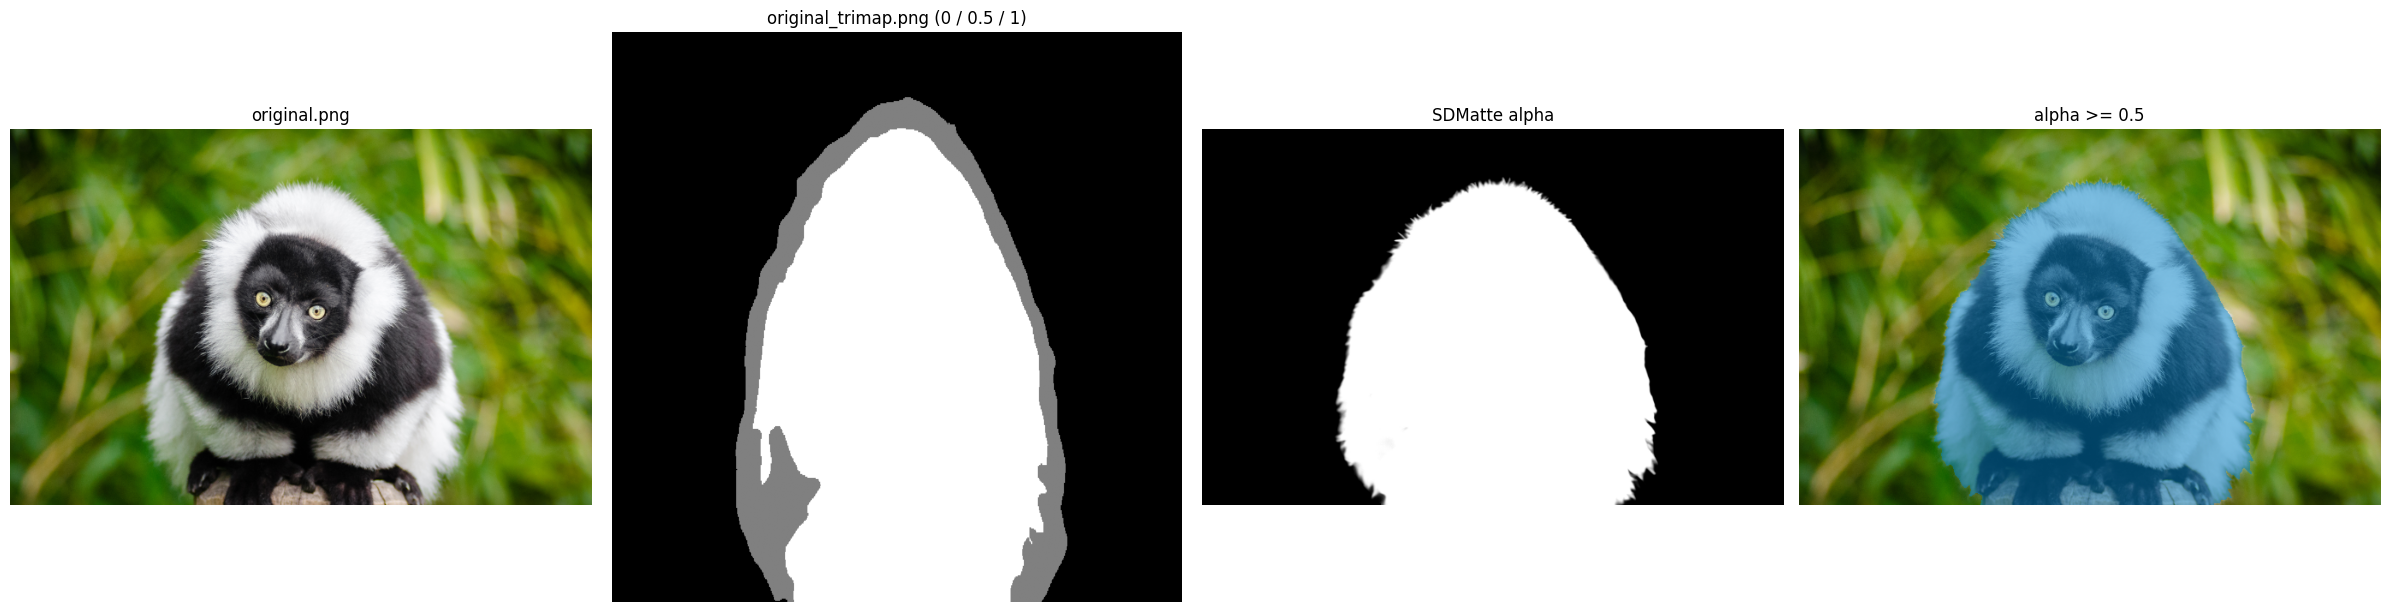

In [14]:
def run_pair(image_path, trimap_path, out_dir=None, thresh=ALPHA_THRESH):
    """SDMatte on one (image, trimap) pair. Returns dict; writes alpha/mask/overlay to out_dir."""
    image_path, trimap_path = Path(image_path), Path(trimap_path)
    out_dir = Path(out_dir) if out_dir else OUT_DIR / image_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    img = ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    trimap = load_trimap_file(trimap_path)

    t0 = time.time()
    alpha = sdmatte_alpha_trimap(img, trimap)
    dt = time.time() - t0
    wall = alpha >= thresh

    Image.fromarray((alpha * 255).astype(np.uint8), "L").save(out_dir / "alpha_sdmatte.png")
    mask_to_pil(wall).save(out_dir / "mask_sdmatte.png")
    trimap_to_pil(trimap, img.size).save(out_dir / "trimap.png")
    overlay = np.asarray(img).astype(np.float32)
    overlay[wall] = 0.5 * overlay[wall] + 0.5 * np.array((0, 130, 200), np.float32)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(out_dir / "overlay.png")

    print(f"  sdmatte {dt:.1f}s | fg {100 * wall.mean():.1f}% of frame -> {out_dir}")
    return {"img": img, "alpha": alpha, "wall": wall, "trimap": trimap, "out_dir": out_dir}


pair = run_pair(ROOT / "original.png", ROOT / "original_trimap.png")

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
ax[0].imshow(pair["img"]);                                      ax[0].set_title("original.png")
ax[1].imshow(pair["trimap"], cmap="gray", vmin=0, vmax=1);      ax[1].set_title("original_trimap.png (0 / 0.5 / 1)")
ax[2].imshow(pair["alpha"], cmap="gray", vmin=0, vmax=1);       ax[2].set_title("SDMatte alpha")
ax[3].imshow(Image.open(pair["out_dir"] / "overlay.png"));      ax[3].set_title(f"alpha >= {ALPHA_THRESH}")
for a in ax:
    a.axis("off")
plt.tight_layout()